# PACSSUN 2603 Time-Domain Plots


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import pytz

## ISAC1

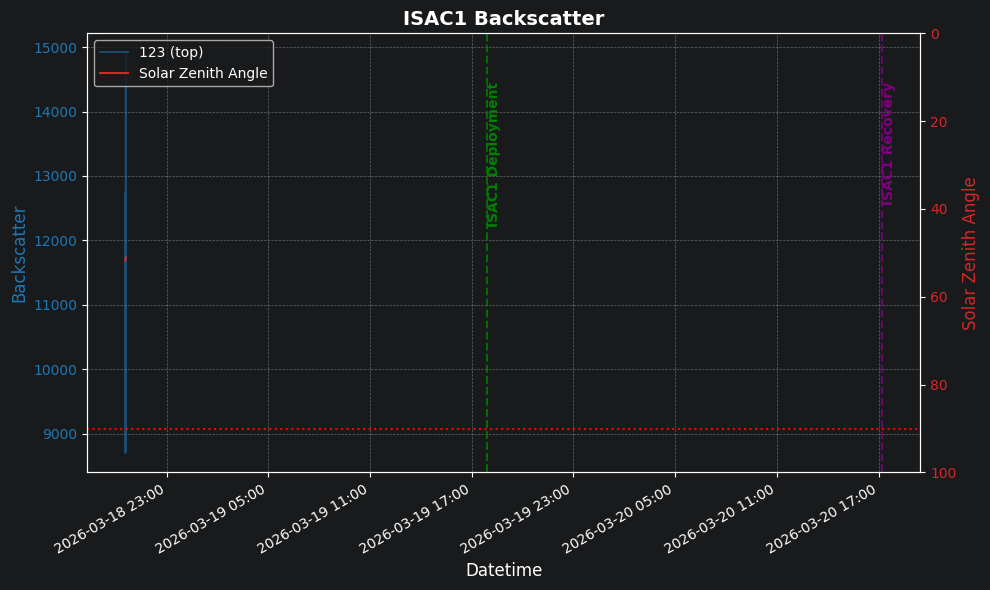

In [37]:
title = 'ISAC1 Backscatter'
df = pd.read_csv('ISAC1.csv')
df['Datetime']=pd.to_datetime(df['Datetime'])

# df = df.sort_values('Datetime')
# Use the object-oriented interface (fig, ax) for easier control of twin axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the data series on the primary (left) y-axis
line1, = ax1.plot(df['Datetime'], df['backscatter_filtered_123'], label='123 (top)', color='tab:blue', alpha = 0.1)
line1, = ax1.plot(df['Datetime'], df['backscatter_filtered_123'], label='123 (top)', color='tab:blue', alpha = 0.5)

# line3, = ax1.plot(df['Datetime'], df['backscatter_113'], label='113 (mid-low)', color='tab:green')

# Create a secondary y-axis for the solar zenith angle
ax2 = ax1.twinx()
line4, = ax2.plot(df['Datetime'], df['zenith'], label='Solar Zenith Angle', color='tab:red')

# Set Axis Labels
ax1.set_xlabel('Datetime', fontsize=12)
ax1.set_ylabel('Backscatter', fontsize=12, color='tab:blue')
ax2.set_ylabel('Solar Zenith Angle', fontsize=12, color='tab:red')

# Match the tick colors to the line colors for clarity
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(0, 100)
ax2.invert_yaxis()  # Zenith is 0° at the top (overhead)
ax2.axhline(90, color='red', linestyle=':', label='Horizon (90°)')

# 1. Define your vertical lines (Date, Label, and Color)
events = [
    (pd.Timestamp('2026-03-20 06:55', tz='Pacific/Tongatapu'), 'ISAC1 Deployment', 'green'),
    (pd.Timestamp('2026-03-21 06:14', tz='Pacific/Tongatapu'), 'ISAC1 Recovery', 'purple'),
]

# 2. Add the lines to the plot
for date, label, col in events:
    # axvline draws the line; transform=ax1.get_xaxis_transform() ensures it spans the plot
    ax1.axvline(x=date, color=col, linestyle='--', linewidth=1.5, alpha=0.8)

    # Add a text label near the top of the plot
    # x=date, y=0.95 (95% up the axis)
    ax1.text(date, ax1.get_ylim()[1] * 0.95, f' {label}',
             color=col, fontweight='bold', verticalalignment='top', rotation=90)

# Combine legends from both axes into one box
# Note: If you want the vertical lines in the legend, you'd add them here
lines = [line1, line4]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')


# Formatting the X-axis (Dates)
fig.autofmt_xdate()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))

# Combine legends from both axes into one box
lines = [line1, line4]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title(title, fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig(title+".png")
plt.show()


In [32]:
df

,unixTime_123,background_123,ambient_123,backscatter_123,pressure_123,waterTemp_123,battery_123,backscatter_filtered_123,ambient_filtered_123,Datetime,...,DeviceDateTime,AgeInSeconds,BatteryVoltage,GpsQuality,Latitude,Longitude,SubmergedBoolean,Temperature0cm,Unnamed: 11,station
0,1773912775,122,181,8709,0,2000,133,NaN,NaN,2026-03-19 09:32:55+13:00,...,3/19/26 7:40,27614,12.0,3,-21.010986,-175.749227,0,NaN,NaN,349
1,1773912775,167,191,8710,0,2000,133,NaN,NaN,2026-03-19 09:32:55+13:00,...,3/19/26 7:40,27614,12.0,3,-21.010986,-175.749227,0,NaN,NaN,349
2,1773912775,210,198,8712,0,2000,133,NaN,NaN,2026-03-19 09:32:55+13:00,...,3/19/26 7:40,27614,12.0,3,-21.010986,-175.749227,0,NaN,NaN,349
3,1773912775,258,195,8713,0,2000,133,NaN,NaN,2026-03-19 09:32:55+13:00,...,3/19/26 7:40,27614,12.0,3,-21.010986,-175.749227,0,NaN,NaN,349
4,1773912775,303,211,8710,0,2000,133,NaN,NaN,2026-03-19 09:32:55+13:00,...,3/19/26 7:40,27614,12.0,3,-21.010986,-175.749227,0,NaN,NaN,349
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3692,1773912941,163909,240,8839,0,2000,91,NaN,NaN,2026-03-19 09:35:41+13:00,...,3/19/26 7:40,27614,12.0,3,-21.010986,-175.749227,0,NaN,NaN,349
3693,1773912941,163954,236,8829,0,2000,91,NaN,NaN,2026-03-19 09:35:41+13:00,...,3/19/26 7:40,27614,12.0,3,-21.010986,-175.749227,0,NaN,NaN,349
3694,1773912941,163997,244,8838,0,2000,91,NaN,NaN,2026-03-19 09:35:41+13:00,...,3/19/26 7:40,27614,12.0,3,-21.010986,-175.749227,0,NaN,NaN,349
3695,1773912941,164042,252,8831,0,2000,91,NaN,NaN,2026-03-19 09:35:41+13:00,...,3/19/26 7:40,27614,12.0,3,-21.010986,-175.749227,0,NaN,NaN,349


Ambient light:

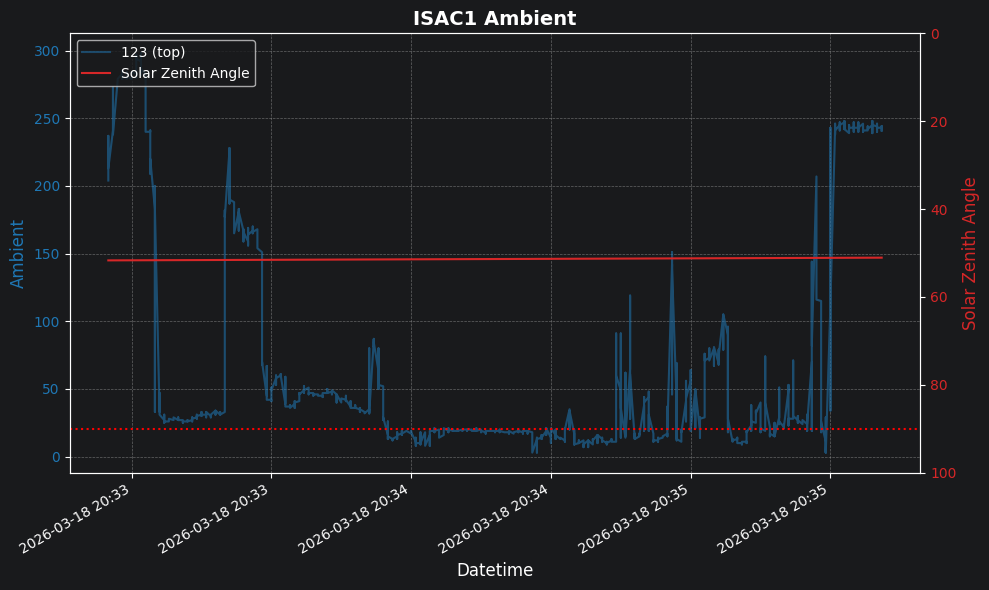

In [19]:
df = pd.read_csv('ISAC1.csv')

# df = df.sort_values('Datetime')
df['Datetime']=pd.to_datetime(df['Datetime'])
# Use the object-oriented interface (fig, ax) for easier control of twin axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the data series on the primary (left) y-axis
line1, = ax1.plot(df['Datetime'], df['ambient_filtered_123'], label='123 (top)', color='tab:blue', alpha = 0.1)
line1, = ax1.plot(df['Datetime'], df['ambient_filtered_123'], label='123 (top)', color='tab:blue', alpha = 0.5)

# line3, = ax1.plot(df['Datetime'], df['backscatter_113'], label='113 (mid-low)', color='tab:green')

# Create a secondary y-axis for the solar zenith angle
ax2 = ax1.twinx()
line4, = ax2.plot(df['Datetime'], df['zenith'], label='Solar Zenith Angle', color='tab:red')

# Set Axis Labels
ax1.set_xlabel('Datetime', fontsize=12)
ax1.set_ylabel('Ambient', fontsize=12, color='tab:blue')
ax2.set_ylabel('Solar Zenith Angle', fontsize=12, color='tab:red')

# Match the tick colors to the line colors for clarity
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(0, 100)
ax2.invert_yaxis()  # Zenith is 0° at the top (overhead)
ax2.axhline(90, color='red', linestyle=':', label='Horizon (90°)')


# Formatting the X-axis (Dates)
fig.autofmt_xdate()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))

# Combine legends from both axes into one box
lines = [line1, line4]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')


title = 'ISAC1 Ambient'
plt.title(title, fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig(title+".png")
plt.show()

## ISAC2

Backscatter:

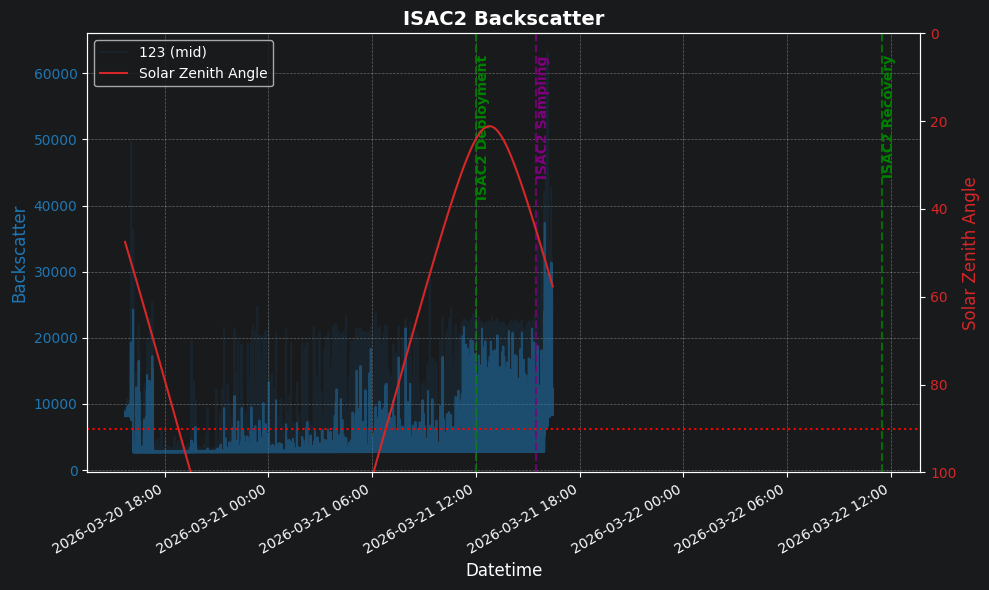

In [20]:
df = pd.read_csv('ISAC2.csv')

# df = df.sort_values('Datetime')
df['Datetime']=pd.to_datetime(df['Datetime']).dt.tz_convert('Pacific/Tongatapu')
# Use the object-oriented interface (fig, ax) for easier control of twin axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the first two series on the primary (left) y-axis
line1, = ax1.plot(df['Datetime'], df['backscatter_123'], label='123 (mid)', color='tab:blue', alpha = 0.1)
line2, = ax1.plot(df['Datetime'], df['backscatter_filtered_123'], label='123 (mid)', color='tab:blue', alpha = 0.5)


# Create a secondary y-axis for the solar zenith angle
ax2 = ax1.twinx()
line4, = ax2.plot(df['Datetime'], df['zenith'], label='Solar Zenith Angle', color='tab:red')

# Set Axis Labels
ax1.set_xlabel('Datetime', fontsize=12)
ax1.set_ylabel('Backscatter', fontsize=12, color='tab:blue')
ax2.set_ylabel('Solar Zenith Angle', fontsize=12, color='tab:red')

# Match the tick colors to the line colors for clarity
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(0, 100)
ax2.invert_yaxis()  # Zenith is 0° at the top (overhead)
ax2.axhline(90, color='red', linestyle=':', label='Horizon (90°)')

# 1. Define your vertical lines (Date, Label, and Color)
events = [
    (pd.Timestamp('2026-03-21 12:00', tz='Pacific/Tongatapu'), 'ISAC2 Deployment', 'green'),
    (pd.Timestamp('2026-03-21 15:30', tz='Pacific/Tongatapu'), 'ISAC2 Sampling', 'purple'),
    (pd.Timestamp('2026-03-22 11:31', tz='Pacific/Tongatapu'), 'ISAC2 Recovery', 'green'),
]

# 2. Add the lines to the plot
for date, label, col in events:
    # axvline draws the line; transform=ax1.get_xaxis_transform() ensures it spans the plot
    ax1.axvline(x=date, color=col, linestyle='--', linewidth=1.5, alpha=0.8)

    # Add a text label near the top of the plot
    # x=date, y=0.95 (95% up the axis)
    ax1.text(date, ax1.get_ylim()[1] * 0.95, f' {label}',
             color=col, fontweight='bold', verticalalignment='top', rotation=90)



# Formatting the X-axis (Dates)
tongatapu_tz = pytz.timezone('Pacific/Tongatapu')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M', tz=tongatapu_tz))

fig.autofmt_xdate()

# Combine legends from both axes into one box
lines = [line1, line4]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

title = 'ISAC2 Backscatter'
plt.title(title, fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig(title+".png")
plt.show()

Ambient:

In [34]:
df

,unixTime_123,background_123,ambient_123,backscatter_123,pressure_123,waterTemp_123,battery_123,backscatter_filtered_123,ambient_filtered_123,Datetime,...,DeviceDateTime,AgeInSeconds,BatteryVoltage,GpsQuality,Latitude,Longitude,SubmergedBoolean,Temperature0cm,Unnamed: 11,station
0,1773912775,122,181,8709,0,2000,133,NaN,NaN,2026-03-19 09:32:55+13:00,...,3/19/26 7:40,27614,12.0,3,-21.010986,-175.749227,0,NaN,NaN,349
1,1773912775,167,191,8710,0,2000,133,NaN,NaN,2026-03-19 09:32:55+13:00,...,3/19/26 7:40,27614,12.0,3,-21.010986,-175.749227,0,NaN,NaN,349
2,1773912775,210,198,8712,0,2000,133,NaN,NaN,2026-03-19 09:32:55+13:00,...,3/19/26 7:40,27614,12.0,3,-21.010986,-175.749227,0,NaN,NaN,349
3,1773912775,258,195,8713,0,2000,133,NaN,NaN,2026-03-19 09:32:55+13:00,...,3/19/26 7:40,27614,12.0,3,-21.010986,-175.749227,0,NaN,NaN,349
4,1773912775,303,211,8710,0,2000,133,NaN,NaN,2026-03-19 09:32:55+13:00,...,3/19/26 7:40,27614,12.0,3,-21.010986,-175.749227,0,NaN,NaN,349
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3692,1773912941,163909,240,8839,0,2000,91,NaN,NaN,2026-03-19 09:35:41+13:00,...,3/19/26 7:40,27614,12.0,3,-21.010986,-175.749227,0,NaN,NaN,349
3693,1773912941,163954,236,8829,0,2000,91,NaN,NaN,2026-03-19 09:35:41+13:00,...,3/19/26 7:40,27614,12.0,3,-21.010986,-175.749227,0,NaN,NaN,349
3694,1773912941,163997,244,8838,0,2000,91,NaN,NaN,2026-03-19 09:35:41+13:00,...,3/19/26 7:40,27614,12.0,3,-21.010986,-175.749227,0,NaN,NaN,349
3695,1773912941,164042,252,8831,0,2000,91,NaN,NaN,2026-03-19 09:35:41+13:00,...,3/19/26 7:40,27614,12.0,3,-21.010986,-175.749227,0,NaN,NaN,349


In [33]:
import time
test_val = 1773912775  # Replace with one of yours
print(f"Standard UTC conversion: {time.strftime('%Y-%m-%d %H:%M:%S', time.gmtime(test_val))}")

Standard UTC conversion: 2026-03-19 09:32:55


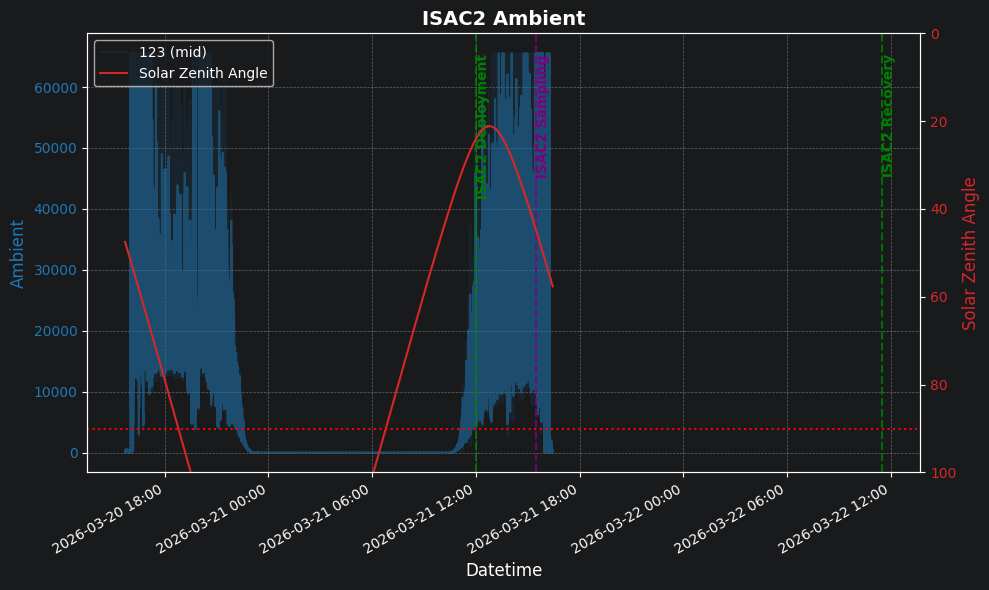

In [23]:
df = pd.read_csv('ISAC2.csv')

# df = df.sort_values('Datetime')
df['Datetime']=pd.to_datetime(df['Datetime']).dt.tz_convert('Pacific/Tongatapu')
# Use the object-oriented interface (fig, ax) for easier control of twin axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the first two series on the primary (left) y-axis
line1, = ax1.plot(df['Datetime'], df['ambient_123'], label='123 (mid)', color='tab:blue', alpha = 0.1)
line2, = ax1.plot(df['Datetime'], df['ambient_filtered_123'], label='123 (mid)', color='tab:blue', alpha = 0.5)


# Create a secondary y-axis for the solar zenith angle
ax2 = ax1.twinx()
line4, = ax2.plot(df['Datetime'], df['zenith'], label='Solar Zenith Angle', color='tab:red')

# Set Axis Labels
ax1.set_xlabel('Datetime', fontsize=12)
ax1.set_ylabel('Ambient', fontsize=12, color='tab:blue')
ax2.set_ylabel('Solar Zenith Angle', fontsize=12, color='tab:red')

# Match the tick colors to the line colors for clarity
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(0, 100)
ax2.invert_yaxis()  # Zenith is 0° at the top (overhead)
ax2.axhline(90, color='red', linestyle=':', label='Horizon (90°)')
# 1. Define your vertical lines (Date, Label, and Color)
events = [
    (pd.Timestamp('2026-03-21 12:00', tz='Pacific/Tongatapu'), 'ISAC2 Deployment', 'green'),
    (pd.Timestamp('2026-03-21 15:30', tz='Pacific/Tongatapu'), 'ISAC2 Sampling', 'purple'),
    (pd.Timestamp('2026-03-22 11:31', tz='Pacific/Tongatapu'), 'ISAC2 Recovery', 'green'),
]

# 2. Add the lines to the plot
for date, label, col in events:
    # axvline draws the line; transform=ax1.get_xaxis_transform() ensures it spans the plot
    ax1.axvline(x=date, color=col, linestyle='--', linewidth=1.5, alpha=0.8)

    # Add a text label near the top of the plot
    # x=date, y=0.95 (95% up the axis)
    ax1.text(date, ax1.get_ylim()[1] * 0.95, f' {label}',
             color=col, fontweight='bold', verticalalignment='top', rotation=90)



# Formatting the X-axis (Dates)
tongatapu_tz = pytz.timezone('Pacific/Tongatapu')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M', tz=tongatapu_tz))

fig.autofmt_xdate()

# Combine legends from both axes into one box
lines = [line1, line4]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

title = 'ISAC2 Ambient'
plt.title(title, fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig(title+".png")
plt.show()

## ISAC3

Backscatter:

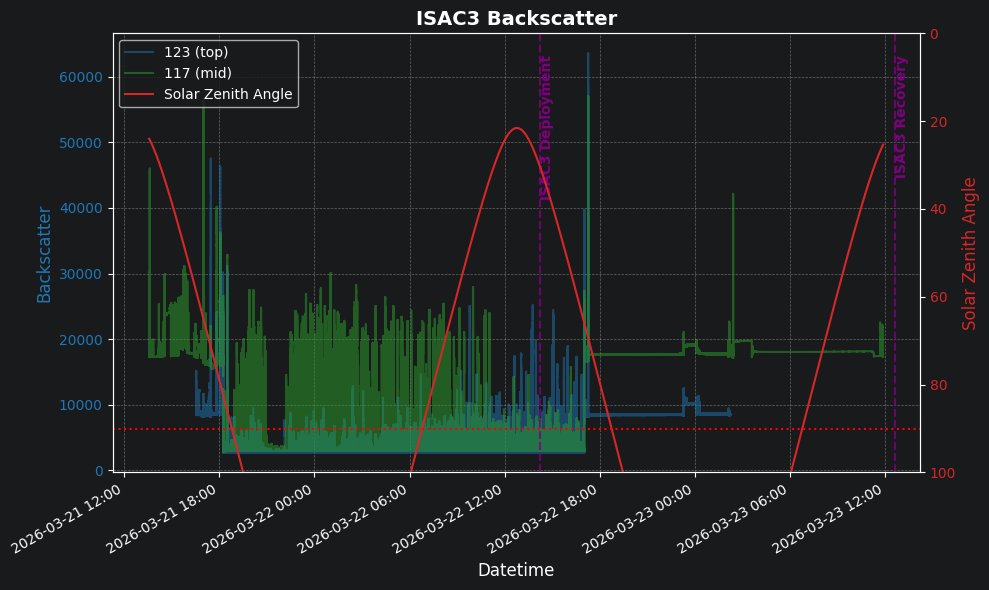

In [35]:
df = pd.read_csv('ISAC3.csv')

# df = df.sort_values('Datetime')
df['Datetime']=pd.to_datetime(df['Datetime']).dt.tz_convert('Pacific/Tongatapu')
# Use the object-oriented interface (fig, ax) for easier control of twin axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the first two series on the primary (left) y-axis
line1, = ax1.plot(df['Datetime'], df['backscatter_filtered_123'], label='123 (top)', color='tab:blue', alpha = 0.5)
line2, = ax1.plot(df['Datetime'], df['backscatter_filtered_117'], label='117 (mid)', color='tab:green', alpha = 0.5)
# line3, = ax1.plot(df['Datetime'], df['backscatter_113'], label='113 (mid-low)', color='tab:green')

# Create a secondary y-axis for the solar zenith angle
ax2 = ax1.twinx()
line4, = ax2.plot(df['Datetime'], df['zenith'], label='Solar Zenith Angle', color='tab:red')

# Set Axis Labels
ax1.set_xlabel('Datetime', fontsize=12)
ax1.set_ylabel('Backscatter', fontsize=12, color='tab:blue')
ax2.set_ylabel('Solar Zenith Angle', fontsize=12, color='tab:red')

# Match the tick colors to the line colors for clarity
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(0, 100)
ax2.invert_yaxis()  # Zenith is 0° at the top (overhead)
ax2.axhline(90, color='red', linestyle=':', label='Horizon (90°)')


# 1. Define your vertical lines (Date, Label, and Color)
events = [
    (pd.Timestamp('2026-03-22 14:13', tz='Pacific/Tongatapu'), 'ISAC3 Deployment', 'purple'),
    # (pd.Timestamp('2026-03-21 15:30', tz='Pacific/Tongatapu'), 'ISAC2 Sampling', 'purple'),
    (pd.Timestamp('2026-03-23 12:38', tz='Pacific/Tongatapu'), 'ISAC3 Recovery', 'purple'),
]

# 2. Add the lines to the plot
for date, label, col in events:
    # axvline draws the line; transform=ax1.get_xaxis_transform() ensures it spans the plot
    ax1.axvline(x=date, color=col, linestyle='--', linewidth=1.5, alpha=0.8)

    # Add a text label near the top of the plot
    # x=date, y=0.95 (95% up the axis)
    ax1.text(date, ax1.get_ylim()[1] * 0.95, f' {label}',
             color=col, fontweight='bold', verticalalignment='top', rotation=90)



# Formatting the X-axis (Dates)
tongatapu_tz = pytz.timezone('Pacific/Tongatapu')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M', tz=tongatapu_tz))

fig.autofmt_xdate()

# Combine legends from both axes into one box
lines = [line1, line2, line4]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

title = 'ISAC3 Backscatter'
plt.title(title, fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig(title+".png")
plt.show()

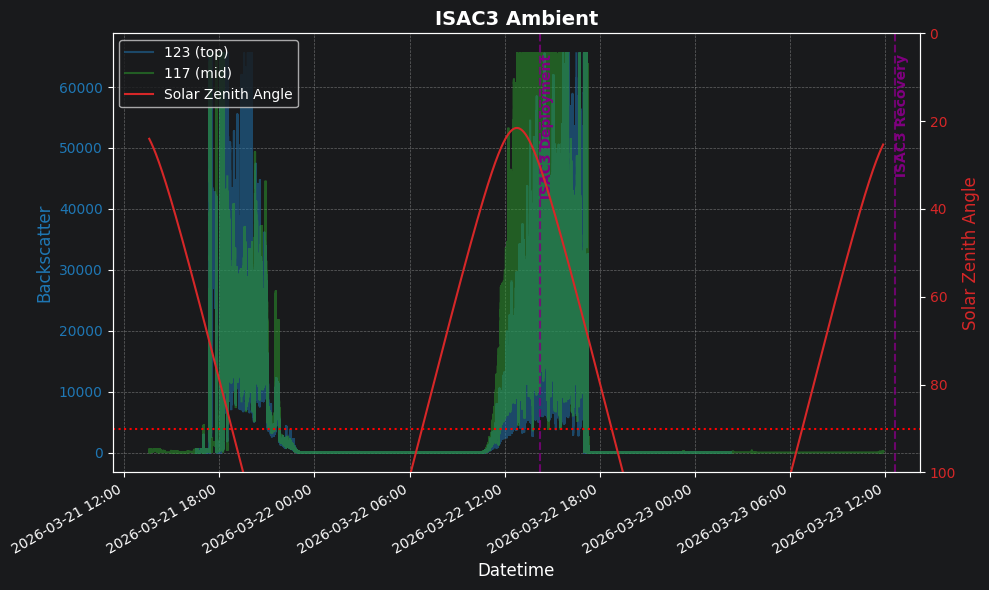

In [26]:
df = pd.read_csv('ISAC3.csv')

# df = df.sort_values('Datetime')
df['Datetime']=pd.to_datetime(df['Datetime'])#.dt.tz_localize'Pacific/Tongatapu')
# Use the object-oriented interface (fig, ax) for easier control of twin axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the first two series on the primary (left) y-axis
line1, = ax1.plot(df['Datetime'], df['ambient_filtered_123'], label='123 (top)', color='tab:blue', alpha = 0.5)
line2, = ax1.plot(df['Datetime'], df['ambient_filtered_117'], label='117 (mid)', color='tab:green', alpha = 0.5)
# line3, = ax1.plot(df['Datetime'], df['backscatter_113'], label='113 (mid-low)', color='tab:green')

# Create a secondary y-axis for the solar zenith angle
ax2 = ax1.twinx()
line4, = ax2.plot(df['Datetime'], df['zenith'], label='Solar Zenith Angle', color='tab:red')

# Set Axis Labels
ax1.set_xlabel('Datetime', fontsize=12)
ax1.set_ylabel('Backscatter', fontsize=12, color='tab:blue')
ax2.set_ylabel('Solar Zenith Angle', fontsize=12, color='tab:red')

# Match the tick colors to the line colors for clarity
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(0, 100)
ax2.invert_yaxis()  # Zenith is 0° at the top (overhead)
ax2.axhline(90, color='red', linestyle=':', label='Horizon (90°)')


# 1. Define your vertical lines (Date, Label, and Color)
events = [
    (pd.Timestamp('2026-03-22 14:13', tz='Pacific/Tongatapu'), 'ISAC3 Deployment', 'purple'),
    # (pd.Timestamp('2026-03-21 15:30', tz='Pacific/Tongatapu'), 'ISAC2 Sampling', 'purple'),
    (pd.Timestamp('2026-03-23 12:38', tz='Pacific/Tongatapu'), 'ISAC3 Recovery', 'purple'),
]

# 2. Add the lines to the plot
for date, label, col in events:
    # axvline draws the line; transform=ax1.get_xaxis_transform() ensures it spans the plot
    ax1.axvline(x=date, color=col, linestyle='--', linewidth=1.5, alpha=0.8)

    # Add a text label near the top of the plot
    # x=date, y=0.95 (95% up the axis)
    ax1.text(date, ax1.get_ylim()[1] * 0.95, f' {label}',
             color=col, fontweight='bold', verticalalignment='top', rotation=90)



# Formatting the X-axis (Dates)
tongatapu_tz = pytz.timezone('Pacific/Tongatapu')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M', tz=tongatapu_tz))

fig.autofmt_xdate()

# Combine legends from both axes into one box
lines = [line1, line2, line4]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

title = 'ISAC3 Ambient'
plt.title(title, fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig(title+".png")
plt.show()

Ambient: